In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Data/Processed/customer_churn_feature_engineered.csv")
print(df.shape)
df.head()

(5000, 23)


,customer_id,gender,age,tenure_months,contract_type,monthly_charges,payment_method,internet_service,support_tickets,complaints,...,satisfaction_score,late_payments,total_charges,churn,tenure_group,monthly_spend_after_discount,support_burden,payment_risk,engagement_level,satisfaction_level
0,CUST00001,Male,68,26,Two Year,1315.66,Debit Card,Unknown,2,2,...,1,1,27365.73,0,25-48 months,1052.5280,4,3,High,Low
1,CUST00002,Female,64,48,One Year,4660.91,Credit Card,Fiber,3,1,...,8,0,190165.13,0,25-48 months,3961.7735,4,1,Low,High
2,CUST00003,Male,64,19,Monthly,966.19,Debit Card,Fiber,1,2,...,6,0,15603.97,0,13-24 months,821.2615,3,2,Medium,Medium
3,CUST00004,Male,21,9,Monthly,2943.45,UPI,Fiber,1,0,...,4,2,25166.50,0,0-12 months,2796.2775,1,2,Low,Medium
4,CUST00005,Male,24,64,One Year,1913.04,Bank Transfer,Fiber,4,2,...,6,1,104069.38,0,49-72 months,1626.0840,6,3,Medium,Medium


In [3]:
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining Churn Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True))


Training Churn Distribution:
churn
0    0.7825
1    0.2175
Name: proportion, dtype: float64

Testing Churn Distribution:
churn
0    0.783
1    0.217
Name: proportion, dtype: float64


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [6]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(numerical_features)
print(categorical_features)

['age', 'tenure_months', 'monthly_charges', 'support_tickets', 'complaints', 'avg_monthly_usage_gb', 'login_frequency', 'discount_percent', 'satisfaction_score', 'late_payments', 'total_charges', 'monthly_spend_after_discount', 'support_burden', 'payment_risk']
['gender', 'contract_type', 'payment_method', 'internet_service', 'tenure_group', 'engagement_level', 'satisfaction_level']


C:\Users\jagdh\AppData\Local\Temp\ipykernel_17020\2938826640.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [7]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [8]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training:", X_train_processed.shape)
print("Testing:", X_test_processed.shape)

Training: (4000, 38)
Testing: (1000, 38)


In [9]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train_processed, y_train)

y_pred = logistic_model.predict(X_test_processed)
print("Predictions:", y_pred[:10])

Predictions: [0 0 0 0 0 0 0 0 0 1]


In [10]:
y_proba = logistic_model.predict_proba(X_test_processed)[:, 1]
print("Predicted Probabilities:", y_proba[:10])

Predicted Probabilities: [0.16819096 0.15180502 0.18845589 0.16899387 0.37289777 0.12268433
 0.07006093 0.05787014 0.14205896 0.57245147]


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

cm = confusion_matrix(y_test, y_pred)

print("\n Confusion Matrix:")
print(cm)

Accuracy : 0.801
Precision: 0.6406
Recall   : 0.1889
F1 Score : 0.2918
ROC-AUC  : 0.7615

 Confusion Matrix:
[[760  23]
 [176  41]]


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.97      0.88       783
           1       0.64      0.19      0.29       217

    accuracy                           0.80      1000
   macro avg       0.73      0.58      0.59      1000
weighted avg       0.77      0.80      0.76      1000



In [14]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

decision_tree_model.fit(X_train_processed, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [15]:
y_pred_dt = decision_tree_model.predict(X_test_processed)
y_probability_dt = decision_tree_model.predict_proba(X_test_processed)[:, 1]

In [16]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_probability_dt)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))
print("ROC-AUC  :", round(roc_auc_dt, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.769
Precision: 0.4054
Recall   : 0.1382
F1 Score : 0.2062
ROC-AUC  : 0.6916

Confusion Matrix:
[[739  44]
 [187  30]]


In [17]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [18]:
y_pred_rf = random_forest_model.predict(X_test_processed)
y_probability_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_probability_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1 Score :", round(f1_rf, 4))
print("ROC-AUC  :", round(roc_auc_rf, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.796
Precision: 0.6512
Recall   : 0.129
F1 Score : 0.2154
ROC-AUC  : 0.7467

Confusion Matrix:
[[768  15]
 [189  28]]


In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)

knn_model.fit(X_train_processed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [20]:
y_pred_knn = knn_model.predict(X_test_processed)
y_probability_knn = knn_model.predict_proba(X_test_processed)[:, 1]

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
roc_auc_knn = roc_auc_score(y_test, y_probability_knn)

print("KNN Results")
print("-----------")
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))
print("ROC-AUC  :", round(roc_auc_knn, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN Results
-----------
Accuracy : 0.777
Precision: 0.4674
Recall   : 0.1982
F1 Score : 0.2783
ROC-AUC  : 0.6491

Confusion Matrix:
[[734  49]
 [174  43]]


In [21]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn
    ],
    "Precision": [
        precision,
        precision_dt,
        precision_rf,
        precision_knn
    ],
    "Recall": [
        recall,
        recall_dt,
        recall_rf,
        recall_knn
    ],
    "F1 Score": [
        f1,
        f1_dt,
        f1_rf,
        f1_knn
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_dt,
        roc_auc_rf,
        roc_auc_knn
    ]
})

model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801,0.6406,0.1889,0.2918,0.7615
1,Decision Tree,0.769,0.4054,0.1382,0.2062,0.6916
2,Random Forest,0.796,0.6512,0.1290,0.2154,0.7467
3,KNN,0.777,0.4674,0.1982,0.2783,0.6491


In [22]:
model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801,0.6406,0.1889,0.2918,0.7615
1,Random Forest,0.796,0.6512,0.1290,0.2154,0.7467
2,Decision Tree,0.769,0.4054,0.1382,0.2062,0.6916
3,KNN,0.777,0.4674,0.1982,0.2783,0.6491


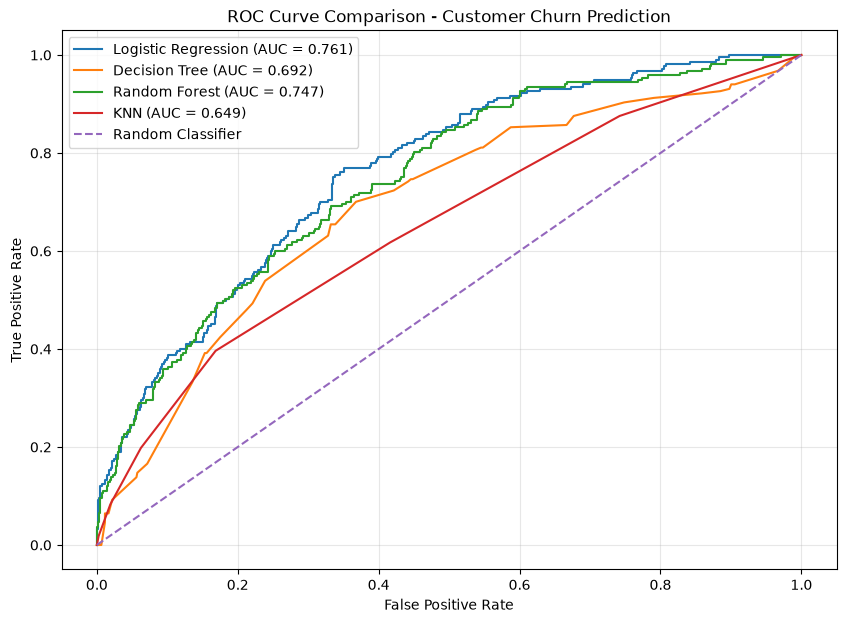

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_probability_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probability_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_probability_knn)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr, tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_dt, tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_dt:.3f})"
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.3f})"
)

plt.plot(
    fpr_knn, tpr_knn,
    label=f"KNN (AUC = {roc_auc_knn:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Customer Churn Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Logistic Regression


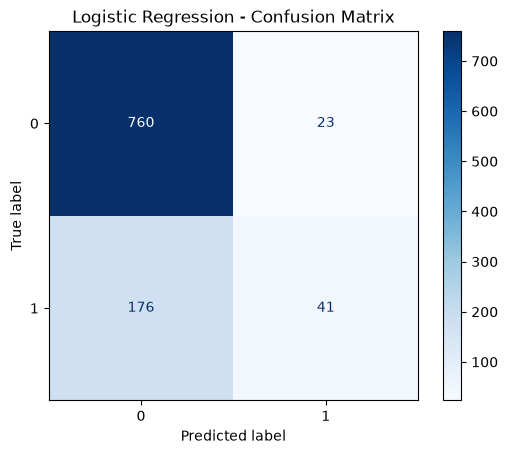


Decision Tree


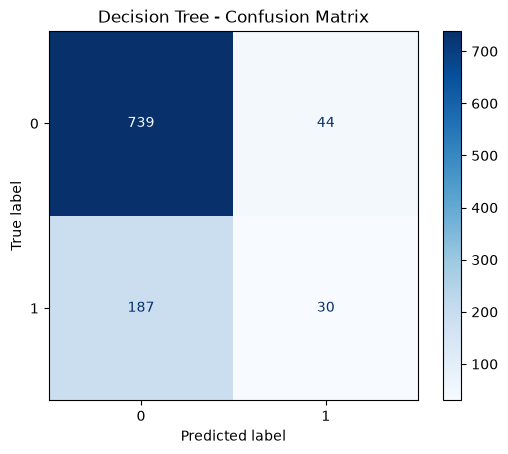


Random Forest


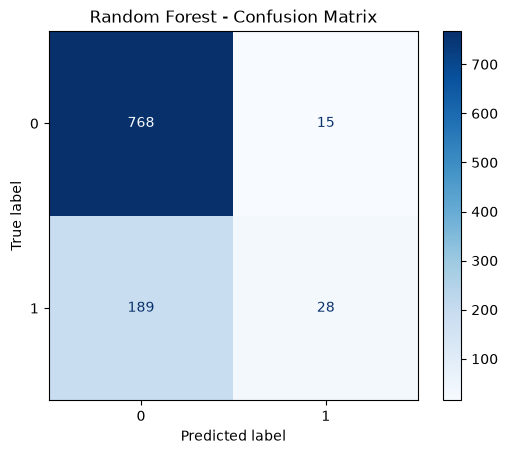


KNN


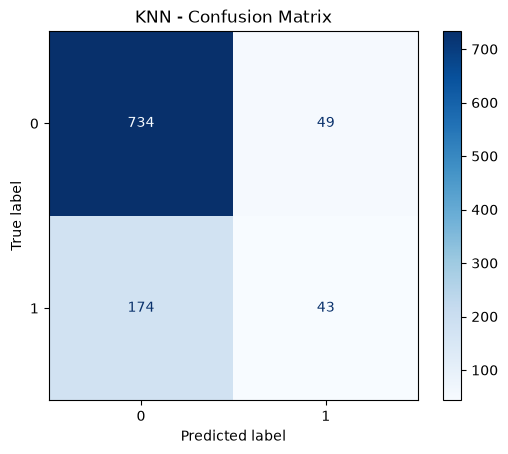

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn
}

for model_name, predictions in models.items():
    print(f"\n{model_name}")
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        cmap="Blues"
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 15
feature_importance.head(15)

,Feature,Importance
0,num__tenure_months,0.081614
1,num__total_charges,0.074594
2,num__monthly_charges,0.072029
3,num__satisfaction_score,0.071348
4,num__monthly_spend_after_discount,0.069922
5,num__avg_monthly_usage_gb,0.066933
6,num__age,0.058696
7,num__login_frequency,0.054410
8,num__support_burden,0.035965
9,num__payment_risk,0.035695


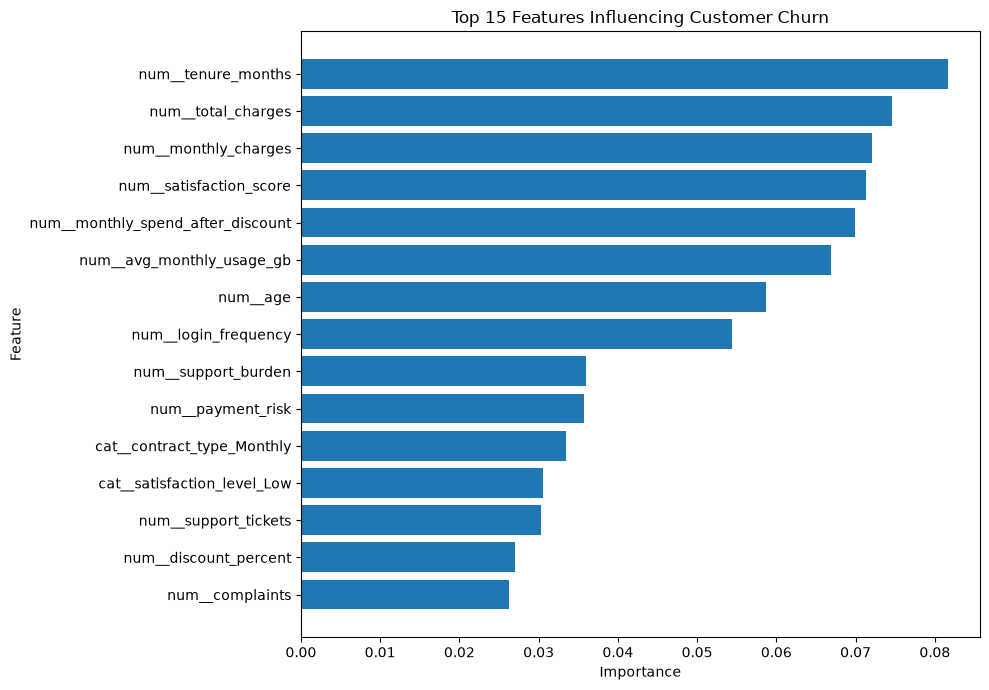

In [26]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Customer Churn")
plt.tight_layout()
plt.show()

In [27]:
# Generate churn probability for the complete dataset

X_all = df.drop(columns=["churn", "customer_id"])

X_all_processed = preprocessor.transform(X_all)

df["churn_probability"] = random_forest_model.predict_proba(
    X_all_processed
)[:, 1]

df["predicted_churn"] = (
    df["churn_probability"] >= 0.50
).astype(int)


In [28]:
def assign_risk(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_level"] = df["churn_probability"].apply(assign_risk)

df[
    [
        "customer_id",
        "churn_probability",
        "predicted_churn",
        "risk_level"
    ]
].head(10)

,customer_id,churn_probability,predicted_churn,risk_level
0,CUST00001,0.208786,0,Low Risk
1,CUST00002,0.086694,0,Low Risk
2,CUST00003,0.068452,0,Low Risk
3,CUST00004,0.397617,0,Low Risk
4,CUST00005,0.118522,0,Low Risk
5,CUST00006,0.229254,0,Low Risk
6,CUST00007,0.086048,0,Low Risk
7,CUST00008,0.091965,0,Low Risk
8,CUST00009,0.654348,1,Medium Risk
9,CUST00010,0.352330,0,Low Risk


In [29]:
print(df["risk_level"].value_counts())

print("\nRisk Percentage:")
print(
    (df["risk_level"].value_counts(normalize=True) * 100)
    .round(2)
)

risk_level
Low Risk       4190
Medium Risk     751
High Risk        59
Name: count, dtype: int64

Risk Percentage:
risk_level
Low Risk       83.80
Medium Risk    15.02
High Risk       1.18
Name: proportion, dtype: float64


In [30]:
retention_priority = df[
    df["risk_level"] == "High Risk"
].sort_values(
    by="churn_probability",
    ascending=False
)

retention_priority[
    [
        "customer_id",
        "contract_type",
        "tenure_months",
        "monthly_charges",
        "support_tickets",
        "complaints",
        "satisfaction_score",
        "late_payments",
        "churn_probability",
        "risk_level"
    ]
].head(20)

,customer_id,contract_type,tenure_months,monthly_charges,support_tickets,complaints,satisfaction_score,late_payments,churn_probability,risk_level
3720,CUST03721,Monthly,6,4671.100,3,3,2,2,0.863026,High Risk
2874,CUST02875,Monthly,5,4657.250,3,2,1,3,0.833396,High Risk
4281,CUST04282,Monthly,12,1763.660,0,4,1,2,0.831675,High Risk
1098,CUST01099,Monthly,11,4833.680,3,2,1,0,0.814349,High Risk
2205,CUST02206,Monthly,3,2706.835,1,4,1,0,0.806566,High Risk
3692,CUST03693,Monthly,8,4804.470,3,1,2,0,0.805856,High Risk
765,CUST00766,Monthly,7,4050.910,2,2,1,3,0.804214,High Risk
683,CUST00684,Monthly,10,4722.870,3,0,2,2,0.800738,High Risk
1411,CUST01412,Monthly,3,2544.820,4,2,1,2,0.793720,High Risk
4809,CUST04810,Monthly,12,4344.010,5,2,3,3,0.793166,High Risk


In [31]:
def retention_action(row):
    if row["risk_level"] == "High Risk":
        if row["satisfaction_score"] <= 3:
            return "Customer Service Intervention"
        elif row["support_tickets"] >= 4:
            return "Priority Support Follow-up"
        elif row["late_payments"] >= 3:
            return "Payment Assistance / Reminder"
        elif row["contract_type"] == "Monthly":
            return "Contract Upgrade Offer"
        else:
            return "Personalized Retention Offer"

    elif row["risk_level"] == "Medium Risk":
        if row["satisfaction_score"] <= 5:
            return "Satisfaction Improvement Campaign"
        elif row["support_tickets"] >= 3:
            return "Support Follow-up"
        else:
            return "Engagement Campaign"

    else:
        return "Regular Engagement"

In [32]:
df["retention_action"] = df.apply(
    retention_action,
    axis=1
)

df[
    [
        "customer_id",
        "churn_probability",
        "risk_level",
        "retention_action"
    ]
].head(20)

,customer_id,churn_probability,risk_level,retention_action
0,CUST00001,0.208786,Low Risk,Regular Engagement
1,CUST00002,0.086694,Low Risk,Regular Engagement
2,CUST00003,0.068452,Low Risk,Regular Engagement
3,CUST00004,0.397617,Low Risk,Regular Engagement
4,CUST00005,0.118522,Low Risk,Regular Engagement
5,CUST00006,0.229254,Low Risk,Regular Engagement
6,CUST00007,0.086048,Low Risk,Regular Engagement
7,CUST00008,0.091965,Low Risk,Regular Engagement
8,CUST00009,0.654348,Medium Risk,Satisfaction Improvement Campaign
9,CUST00010,0.352330,Low Risk,Regular Engagement


In [33]:
action_summary = (
    df["retention_action"]
    .value_counts()
    .reset_index()
)

action_summary.columns = [
    "Retention Action",
    "Customer Count"
]

action_summary

,Retention Action,Customer Count
0,Regular Engagement,4190
1,Satisfaction Improvement Campaign,607
2,Engagement Campaign,83
3,Support Follow-up,61
4,Customer Service Intervention,56
5,Priority Support Follow-up,2
6,Contract Upgrade Offer,1


In [34]:
import os

output_folder = os.path.join(
    os.getcwd(),
    "Data",
    "Processed"
)

os.makedirs(output_folder, exist_ok=True)

final_file_path = os.path.join(
    output_folder,
    "customer_churn_ml_output.csv"
)

df.to_csv(
    final_file_path,
    index=False
)

print("Final ML dataset saved successfully!")
print(final_file_path)
print("\nFile exists:", os.path.exists(final_file_path))

Final ML dataset saved successfully!
e:\Customer_Churn_Project\NoteBooks\Data\Processed\customer_churn_ml_output.csv

File exists: True


In [35]:
model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.801,0.6406,0.1889,0.2918,0.7615
1,Decision Tree,0.769,0.4054,0.1382,0.2062,0.6916
2,Random Forest,0.796,0.6512,0.1290,0.2154,0.7467
3,KNN,0.777,0.4674,0.1982,0.2783,0.6491


In [36]:
model_comparison.to_csv(
    "Data/Processed/model_comparison.csv",
    index=False
)

In [37]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(
    random_forest_model,
    "models/random_forest_churn_model.pkl"
)

joblib.dump(
    preprocessor,
    "models/preprocessor.pkl"
)

['models/preprocessor.pkl']